### Visualizing the phaseflip code

In [1]:
include("functions.jl")
using Plots, JLD2, LaTeXStrings, FileIO

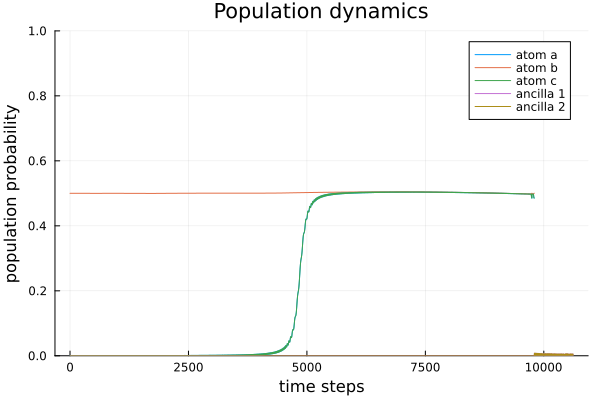

In [2]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/N_atoms=5_γ_decay=0.0_Ntraj=1.jld2"

population_data = population_data;
# hadamard_population_data = hadamard_population_data;
# ancilla_population_data = ancilla_population_data;
# corrected_population_data = corrected_population_data;
# fidelity_data = fidelity_data;


plot(population_data[:a],  ylim=[0,1], label="atom a", xlabel="time steps", ylabel="population probability", title="Population dynamics")
plot!(population_data[:b], label="atom b")
plot!(population_data[:c], label="atom c")
plot!(population_data[:a1], label="ancilla 1")
plot!(population_data[:a2], label="ancilla 2")



# plot!(population_data[:a1],label="ancilla 1")
# plot!(population_data[:a2], label="ancilla 2")

### Debugging phaseflip code

In [1]:
using QuantumOptics
using DifferentialEquations
using SparseArrays
using Plots
using LinearAlgebra

In [2]:
struct qubit_parameters
    Ω::Float64
    γ_Decay::Float64
    γ_dephase::Float64
    V_nn::Float64
    δ1::Float64
    δ2::Float64
end

function full_operator(gate, total_qubits, sites)
    """
    Applies an arbitrary gate on a specified site `i` in a `total_qubits`-qubit system.
    All other sites are identity operators.

    Args:
    - gate: AbstractOperator (arbitrary gate to apply on site `i`)
    - i: Array (site index to apply the gate, 1-based)
    - total_qubits: Int (total number of qubits)

    Returns:
    - operator: AbstractOperator (the full operator acting on the entire system)
    """
    # Ensure the gate is an AbstractOperator
    if !(gate isa AbstractOperator)
        throw(ArgumentError("The gate must be an AbstractOperator"))
    end

    # Create an identity operator for each qubit
    identity = transition(NLevelBasis(2), 1,1) + transition(NLevelBasis(2), 2,2)
    identity = Operator(identity.basis_l, identity.basis_r, SparseMatrixCSC{ComplexF32, Int64}(identity.data))
    identity_ops = [identity for _ in 1:total_qubits]
    
    # Replace the identity operator at site `i` with the provided gate
    for j in sites
        identity_ops[j] = gate
    end

    # Return the Kronecker product of all operators
    return tensor(reverse(identity_ops)...)
end


function get_qubit_parameters(p::qubit_parameters,t::Float64,mode::Symbol)
    """
    Function to get the parameters of the system at time t for the qubits
   
    Modes:
        - `:T1` → 0<=t<=T1: Pulse for the qubits A-B-C
        - `:T2` → 0<=t<=T2: Pulse for the ancillas 1-2
        - `:T3` → 0<=t<=T3: Pulse for the qubits A or C
        - `:T4` → 0<=t<=T3: Pulse for the qubit B

    Parameters: 
        - p:: qubit_parameters → Struct containing the qubit parameters
        - time t:: Float64
        - mode:: Symbol → Selects phase (`:T1` or `:T2` or `:T3` or `:T4`)

    Returns: 
        - parameters at time t:: Tuple
    """

    @assert mode in [:T1, :T2, :T3, :T4a, :T4b, :T5] "Invalid mode selected"

    #### Qubit Encoding Modes
    if mode == :T1
        Δt = Δ1_0 - p.δ1 * t
        return [p.Ω/2, p.Ω/2, Δt, Δt, p.V_nn, p.V_nn]

    #### Hadamard Mode 1    
    elseif mode == :T2
        return [p.Ω/2, p.Ω/2, p.Ω/2]
    
    #### Ancilla driving mode
    elseif mode == :T3
        Δt = Δ2_0 - p.δ2 * t
        return [p.Ω/2, p.Ω/2, Δt, Δt, p.V_nn/(2^6), p.V_nn/(2^6), p.V_nn/(2^6), p.V_nn/(2^6)]
    
    #### Correction mode for Atom A or C   
    elseif mode == :T4a
        Δt = Δac_0 - p.δ2 * t
        return [p.Ω/2, Δt, p.V_nn, p.V_nn/(2^6)]

    #### Correction mode for Atom B
    elseif mode == :T4b
        Δt = Δb_0 - p.δ2 * t
        return [p.Ω/2, Δt, p.V_nn, p.V_nn, p.V_nn/(2^6), p.V_nn/(2^6)]

    #### Hadamard Mode 2
    elseif mode == :T5
        return [p.Ω/2, p.Ω/2, p.Ω/2]

    end

end

get_qubit_parameters (generic function with 1 method)

In [3]:
total_qubits = 3
T1 = 970.0
T2_y = pi/2;
T2_z = pi;
basi = NLevelBasis(2)
p = qubit_parameters(1.0, 0.0, 0.0, -1000.0, 0.066, 0.108)
const Δ1_0 = 1032.0


const tspan1 = [0.0:0.1:T1;]

# System Hamiltonian 1 - driving atoms A-C
σx = transition(basi,1,2) + transition(basi,2,1)
σx_a = full_operator(σx, total_qubits, [1])
σx_b = full_operator(σx, total_qubits, [2])
σx_c = full_operator(σx, total_qubits, [3])

n = transition(basi,2,2)
n_b = full_operator(n, total_qubits, [2])
const n_a = full_operator(n, total_qubits, [1])
const n_c = full_operator(n, total_qubits, [3])
const nn_ab = full_operator(n, total_qubits, [1,2])
const nn_bc = full_operator(n, total_qubits, [2,3])
const coeff1 = [t->get_qubit_parameters(p,t,:T1)]
const H1 = LazySum([coeff1[1](tspan1[1])[i] for i ∈ 1:6],[σx_a, σx_c, n_a, n_c, nn_ab, nn_bc])


const tspan2_y = [0.0:0.1:T2_y;]  #Time span for applying hadamards on atoms A-B-C
const tspan2_z = [0.0:0.1:T2_z;]  #Time span for applying hadamards on atoms A-B-C
σy = -im * transition(basi,1,2) + im * transition(basi,2,1)
σy_a = full_operator(σy, total_qubits, [1])
σy_b = full_operator(σy, total_qubits, [2])
σy_c = full_operator(σy, total_qubits, [3])

σz = transition(basi,1,1) - transition(basi,2,2)
σz_a = full_operator(σz, total_qubits, [1])
σz_b = full_operator(σz, total_qubits, [2])
σz_c = full_operator(σz, total_qubits, [3])

const coeff2 = [t->get_qubit_parameters(p,t,:T2)]
const H2_y = LazySum([coeff2[1](tspan2_y[1])[i] for i ∈ 1:3],[σy_a, σy_b, σy_c])
const H2_z = LazySum([coeff2[1](tspan2_z[1])[i] for i ∈ 1:3],[σz_a, σz_b, σz_c])

LazySum(dim=8x8)
  basis: [NLevel(N=2) ⊗ NLevel(N=2) ⊗ NLevel(N=2)]
  operators: 3

In [4]:
function Ht1(t)
    """
    Function to calculate the time dependent Hamiltonian for the MCWF method till time steps T1+T2.
        -- H1: Hamiltonian for driving atoms A-B-C for time 0:T1
        -- H2: Hamiltonian for applying hadamards on atoms A-B-C for time T1:T2
        -- H3: Hamiltonian for driving atoms 1-2 for time T2:T3
    
    Args:
        t:: Float64: Time
    
    Returns:
        H:: LazySum: Time dependent Hamiltonian
    """

    t<T1 || t==T1
    coeffs = coeff1[1](t)
    for i in eachindex(coeffs)
        H1.factors[i] = coeffs[i]
    end
    return H1

end

function Ht2(t)

    if t<(T2_z) || t==(T2_z)
        coeffs = coeff2[1](t)
        for i in eachindex(coeffs)
            H2_z.factors[i] = coeffs[i]
        end
        return H2_z

    elseif t<(T2_y+T2_z) || t==(T2_y+T2_z)
        coeffs = coeff2[1](t)
        for i in eachindex(coeffs)
            H2_y.factors[i] = coeffs[i]
        end
        return H2_y

    # elseif t<(T1+T2+T3) || t==(T1+T2+T3)
    #     coeffs = coeff3[1](t-(T1+T2))
    #     for i in eachindex(coeffs)
    #         H3.factors[i] = coeffs[i]
    #     end
        # return H3
    end 

end


function lindbaldian_dephase(γ_dephase::Float64,site::Array)
    """
    Function to calculate the Lindbaldian dephase operator for the MCWF method.
    The dephase operators are returned according to given respective sites.

    Args:
        γ_dephase:: Float64: Dephase rate
        site:: Array: Array of sites at which the decay operator acts

    Returns:
        C:: Array{Matrix}: Array of dephase operators acting on the system
    """
    basis = NLevelBasis(2)
    σ_z= transition(basis,1,1) - transition(basis,2,2)
    σ_z = Operator(σ_z.basis_l, σ_z.basis_r, SparseMatrixCSC{ComplexF32, Int64}(σ_z.data))

    identity = transition(basis,1,1) + transition(basis,2,2)
    identity = Operator(identity.basis_l, identity.basis_r, SparseMatrixCSC{ComplexF32, Int64}(identity.data))
    C = Vector{Operator}(undef, total_qubits)
    
    for i in 1:total_qubits
        if i in site
            C[i] = sqrt(γ_dephase) .* full_operator(σ_z, total_qubits, [i])
        else
            C[i] = full_operator(identity, total_qubits, [i])
        end
    end

    return C
end

const C = lindbaldian_dephase(0.0,[1,2,3,4,5])    
const Cdagger = [adjoint(c) for c in C]

function f1(t,ψ)
"""
Function to calculate the time evolution of the system using the MCWF method.

Args:
    t:: Float64: Time

Returns:
    H:: LazySum: Time dependent Hamiltonian
    C:: Array{Operator}: Array of decay operators acting on the system
    Cdagger:: Array{Operator}: Array of adjoint decay operators acting on the system
"""

    H = Ht1(t)

    return H, C, Cdagger
end

function f2(t,ψ)
"""
Function to calculate the time evolution of the system using the MCWF method.
Args:
    t:: Float64: Time
Returns:
    H:: LazySum: Time dependent Hamiltonian
    C:: Array{Operator}: Array of decay operators acting on the system
    Cdagger:: Array{Operator}: Array of adjoint decay operators acting on the system
"""

    H = Ht2(t)

    return H, C, Cdagger
end

f2 (generic function with 1 method)

In [5]:
# tspan = [0.0:0.1:(T1);]  #Time span for applying hadamards on atoms A-B-C

g = [1.0,0.0]
r = [0.0,1.0]
α = 1/sqrt(2)
β = 1/sqrt(2)


site_states = [g for _ in 1:total_qubits]
site_states[2] = α.*g + β.*r

ψ0 = reduce(kron, site_states)

full_basis = CompositeBasis([NLevelBasis(2) for _ in 1:total_qubits]...)
ψ0_ket = Ket(full_basis, ComplexF32.(ψ0));

In [6]:
tout, ψt, jumps = timeevolution.mcwf_dynamic(tspan1,ψ0_ket,f1, maxiters=1e9, seed=(1), display_jumps=true);

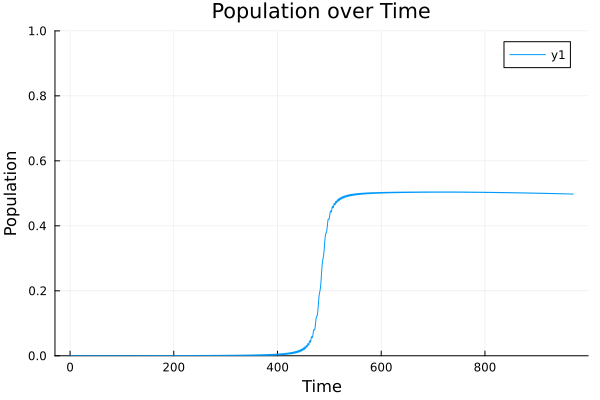

In [7]:
pop = zeros(length(tspan1))
pop .+= real(expect(n_c, ψt))

plot(tspan1, pop, ylim=[0, 1], title="Population over Time", xlabel="Time", ylabel="Population")

In [8]:
a = [r,r,r]
b = [g,g,g]
ψ_ideal = α*reduce(kron,a)+ β*reduce(kron,b)
ψ_target = ψ_ideal / norm(ψ_ideal);

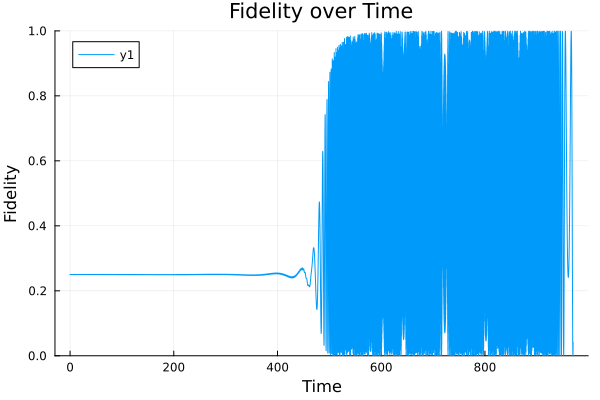

In [9]:
fidelities = []
for i in 1:length(ψt)
    ψt[i] = ψt[i] / norm(ψt[i]) 
    
    fidelity = abs(ψ_target' * ψt[i].data)^2
    push!(fidelities, fidelity)
end

plot(tspan1, fidelities, ylim=[0, 1], title="Fidelity over Time", xlabel="Time", ylabel="Fidelity")

In [10]:
ψ_end = ψt[end].data/norm(ψt[end].data)
fidelity = real(abs(ψ_target' * ψ_end)^2)
println("Fidelity: ", fidelity)

Fidelity: 0.04206479199918125


#### Dynamical Phase Correction

In [11]:
struct PrecomputedOps{T}
    σminus_sys::Vector{Matrix{T}}
    σplus_sys::Vector{Matrix{T}}
    σx_sys::Vector{Matrix{T}}
    σz_sys::Vector{Matrix{T}}
    n_sys::Vector{Matrix{T}}
    nn_sys::Vector{Matrix{T}}
end

function PrecomputedOps(n_atoms::Int=3)
    σ_x     = [0 1; 1 0]
    σ_minus = [0 1; 0 0]
    σ_plus  = [0 0; 1 0]
    σ_z     = [1 0; 0 -1]
    n       = [0 0; 0 1]
    I       = [1 0; 0 1]

    make(op) = [reduce(kron, [i==k ? op : I for i=1:n_atoms]) for k=1:n_atoms]

    return PrecomputedOps(
        make(σ_minus), make(σ_plus), make(σ_x),
        make(σ_z),     make(n),      [kron(n,n,I), kron(I,n,n)]
    )
end

const OPS = PrecomputedOps()


# p_tuple = (Ω,γ_Decay,γ_dephase,V_nn,δ1,Δ1_0,Δ2_0,OPS)
p_tuple = (1.0, 0.0, 0.0, -1000.0, 0.066, 1032.0, 1032.0, OPS)


function energy_level_spaghetti(time::Array,p)
    """
    Function to calculate the energy levels of the system at different time steps.
    Args:
        time:: Array: Array of time steps
        p:: Tuple: Parameters of the system
    Returns:
        - e:: Array: Array of energy levels
        - e_vec:: Array: Array of eigenvectors
        - Delta:: Array: Array of detuning values
    """
    # Unpack the solution object
    t_vals = time  
    e = []
    e_vec = []
    Delta = []

    for t in t_vals

        #parameters
        Ω, γ_Decay, γ_dephase, V_nn, δ, Δ1_0, Δ2_0, ops = p
        Δ_t = Δ1_0 - δ*t

        # unpack the pre‑built operators ↓
        σx_sys, σminus_sys, σplus_sys,
        σz_sys, n_sys, nn_sys = ops.σx_sys, ops.σminus_sys, ops.σplus_sys,
                                ops.σz_sys, ops.n_sys, ops.nn_sys

        #Hamiltonian
        H = Ω/2 .* σx_sys[1] + Ω/2 .* σx_sys[3] + V_nn .* nn_sys[1] + V_nn.* nn_sys[2] +
            Δ_t .* n_sys[1] + Δ_t .* n_sys[3]

        eigenvals = eigen(H,sortby=nothing).values
        eigvecs = eigen(H,sortby=nothing).vectors
        push!(e_vec, eigvecs)
        push!(e, eigenvals)
        push!(Delta, Δ_t)
    end

    return e, e_vec, Delta
end


function trapezoidal_integrate(t,E1,E2)
    """
    Function to compute the dynamical phase using the trapezoidal rule for numerical integration.
    Args:
        t:: Array: Array of time steps
        E1:: Array: Array of energy levels for the first state
        E2:: Array: Array of energy levels for the second state
    Returns:
        - Δ0_dyn:: Float64: Dynamical phase
        - ΔEs:: Array: Array of energy differences
    """
        # Trapezoidal rule for numerical integration
        ΔEs = E2 .- E1
        Δ0_dyn = -2*π* sum(diff(t) .* (ΔEs[1:end-1] .+ ΔEs[2:end]) / 2)
        return Δ0_dyn, ΔEs
end


function compute_dynamical_phase(t::Array)
    """
    Function to compute the dynamical phase of the system.
    Args:
        t:: Array: Array of time steps
        E1:: Array: Array of energy levels for the first state
        E2:: Array: Array of energy levels for the second state

    Returns:
        - Δ0_dyn:: Float64: Dynamical phase
    """

    # Calculate the energy levels
    energy_levels, _, Delta = energy_level_spaghetti(t,p_tuple)

    #ggg energy level
    e_ggg = [subarray[4] for subarray in energy_levels]

    #rrr energy level
    e_rrr = [subarray[1] for subarray in energy_levels]

    Δ0_dyn, _ = trapezoidal_integrate(t,e_ggg,e_rrr)
    Δ0_dyn = mod(Δ0_dyn,2π)

    return Δ0_dyn, Delta
end

function apply_dynamical_phase(Δ0_dyn::Float64, ψ_obtained::Ket)
    """
    Function to apply the dynamical phase correction to the system.
    Args:
        - Δ0_dyn:: Float64: Dynamical phase

    Returns:
        - ψ_target:: Array: Target state after applying the dynamical phase correction
    """

    # ψ_target = α * reduce(kron,[g,g,g]) + exp(im * Δ0_dyn) * β * reduce(kron,[r,r,r])
    # ψ_target = ψ_target / norm(ψ_target)

    Rz_minus = Operator(NLevelBasis(2), [exp(-im * Δ0_dyn/2) 0; 0 exp(im * Δ0_dyn/2)])
    Rz_correction = full_operator(Rz_minus, total_qubits, [1,3])

    ψ_corrected = Rz_correction * (ψ_obtained/norm(ψ_obtained))
    # ψ_corrected = ψ_corrected / norm(ψ_corrected)

    return ψ_corrected
end

apply_dynamical_phase (generic function with 1 method)

In [14]:
Δ_dyn, Delta = compute_dynamical_phase(tspan1)
ψt_end_corrected = apply_dynamical_phase(Δ_dyn/2, ψt[end])
ψt_end_dyn = ψt_end_corrected.data

encoding_fidelity = abs(ψt_end_dyn' * ψ_target)^2
println("Fidelity of the target state with the final state is $(encoding_fidelity)")

Fidelity of the target state with the final state is 0.9814784261129029


#### Applying Hadamard gates

In [15]:
tspan2 = [0.0:0.1:(T2_y+T2_z);]  #Time span for applying hadamards on atoms A-B-C

# full_basis = CompositeBasis([NLevelBasis(2) for _ in 1:total_qubits]...)
# ψ2_0 = Ket(full_basis, ComplexF32.(ψ_target));
tout, ψt, jumps = timeevolution.mcwf_dynamic(tspan2, ψt_end_corrected, f2, maxiters=1e9, seed=(1), display_jumps=true);

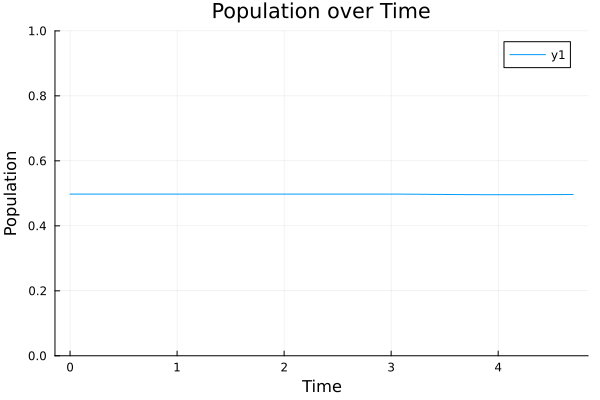

In [23]:
pop_h = zeros(length(tspan2))
pop_h .+= real(expect(n_c, ψt))
plot(tspan2, pop_h, ylim=[0,1], title="Population over Time", xlabel="Time", ylabel="Population")